# Image Preprocessing for CNN Training

## Introduction
In this lesson, we will cover the steps involved in preprocessing images before feeding them into a Convolutional Neural Network (CNN) for training. We will start with a tuple of images and their labels, then normalize all the images to the same size and apply necessary transformations. This preprocessing is crucial for achieving better performance and consistency during training.

## Group Discussion Question
Why is preprocessing important in image-based machine learning models? How does normalizing image sizes and applying consistent transformations help improve the performance of a CNN?

## Loading and Displaying Images
Let's begin by loading and displaying a few images along with their labels.

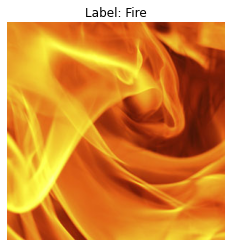

In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Define the directory containing images
image_directory = '/Users/romanpaolucci/Desktop/Saddle River Day/Courses (current)/Artificial Intelligence/Course Materials/Unit 3 - Computer Vision/3.1 Managing Images'

# Initialize lists to store images and labels
images = []
labels = []

# Define a function to load images from a directory
def load_images_from_directory(directory):
    for filename in os.listdir(directory):
        if filename.endswith('.jpg') or filename.endswith('.png'):
            img_path = os.path.join(directory, filename)
            img = Image.open(img_path)
            images.append(img)
            
            # Either 1:
            # Assume labels are part of the filename, e.g., 'cat_01.jpg'
            #label = filename.split('_')[0]
            #labels.append(label)
            
            # Or 2:
            # Assume the directory has the same image labels
            labels.append('Fire')

# Load images and labels
load_images_from_directory(image_directory)

# Display the first image and its label
plt.imshow(images[0])
plt.title(f'Label: {labels[0]}')
plt.axis('off')
plt.show()


### Resizing the Images

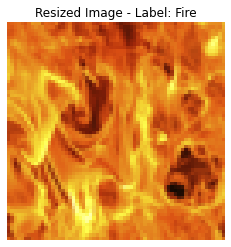

In [5]:
# Define the target size for normalization
target_size = (64, 64)

# Function to resize images
def resize_images(images, target_size):
    resized_images = []
    for img in images:
        resized_img = img.resize(target_size)
        resized_images.append(resized_img)
    return resized_images

# Resize images
resized_images = resize_images(images, target_size)

# Display the first resized image
plt.imshow(resized_images[0])
plt.title(f'Resized Image - Label: {labels[0]}')
plt.axis('off')
plt.show()

### Casting Images to Numpy Arrays

In [6]:
import numpy as np

# Function to convert images to numpy arrays
def images_to_numpy(images):
    image_arrays = []
    for img in images:
        img_array = np.array(img)
        image_arrays.append(img_array)
    return np.array(image_arrays)

# Convert resized images to numpy arrays
image_data = images_to_numpy(resized_images)

# Display the shape of the numpy array
print(f'Shape of image data: {image_data.shape}') # 3 color channels, 64 values, 64 values, 3 samples

Shape of image data: (3, 64, 64, 3)


### Normalizing Pixel Values

Before feeding into a CNN we want pixel values to be normalized by 255.

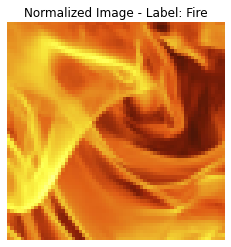

In [7]:
# Normalize pixel values to [0, 1]
image_data = image_data / 255.0

# Display the first normalized image
plt.imshow(image_data[0])
plt.title(f'Normalized Image - Label: {labels[0]}')
plt.axis('off')
plt.show()


### Label Encoding

In [8]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
one_hot_labels = to_categorical(encoded_labels)

# Display the first label and its one-hot encoded format
print(f'Label: {labels[0]}, Encoded: {encoded_labels[0]}, One-hot: {one_hot_labels[0]}')

2024-06-08 19:09:30.298337: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Label: Fire, Encoded: 0, One-hot: [1.]


### Training/Testing Split

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(image_data, one_hot_labels, test_size=0.2, random_state=42)

# Display the shape of the training and testing sets
print(f'Training set shape: {X_train.shape}, {y_train.shape}')
print(f'Testing set shape: {X_test.shape}, {y_test.shape}')

### Practice Problems

1. Modify the code to handle grayscale images instead of RGB images. Display the first grayscale image.

2. Implement additional image transformations such as rotation, flipping, or shifting. Apply these transformations to the dataset and display the results.

3. Write a function to visualize a batch of images with their labels in a grid format.

4. Extend the preprocessing pipeline to handle multiple classes and more complex datasets. Display the first image and its label from each class.

### Conclusion

In this lesson, we covered the steps involved in preprocessing images before training a CNN. We loaded and displayed images, normalized their sizes, converted them to numpy arrays, normalized pixel values, encoded labels, and split the data into training and testing sets. 

These preprocessing steps are essential for achieving better performance and consistency in CNN training.